# Tobit 模型：受限因变量、潜变量与边际效应

> 本讲义用于《金融数据分析与建模》课程。配套文件 `04_tobit_model_codes.ipynb` 用于生成 `./figs/` 中的配图和 `./data/tobit_rd_sim.csv`。

本章围绕一个问题展开：当因变量在 0 附近出现大量堆积时，能否直接用 OLS？答案取决于这些 0 的经济含义。Tobit 模型不是“有很多 0 就用”的模型，而是适用于“潜在连续变量被删失”这一类数据生成过程。

本章聚焦以下问题：

- 理解 Tobit 模型背后的潜变量设定；
- 区分删失、截断、边角解和样本选择；
- 理解 Tobit 为什么需要用似然函数估计；
- 掌握 Python 和 Stata 中估计 Tobit 模型的基本流程；
- 解释 Tobit 系数和三类边际效应；
- 形成可复用的受限因变量分析框架。

## 引言：为什么需要 Tobit 模型

### 金融数据中的大量 0

在金融和企业数据中，我们经常遇到一类变量：

- 企业研发投入强度；
- 企业环保投资；
- 企业慈善捐赠；
- 家庭股票投资额；
- 企业获得的政府补贴；
- 银行贷款金额或保险赔付金额。

这些变量通常有两个特征：第一，取值不能为负；第二，有相当比例的样本集中在 0 点。

以企业研发投入为例，数据库中常见的结果是：一部分企业没有研发投入，$rd_i=0$；另一部分企业有正的研发投入，$rd_i>0$。如果直接把 $rd_i$ 当作普通连续变量做 OLS，模型会忽略 0 点堆积背后的机制。

### OLS 的问题

设潜在变量模型为：

$$
y_i^* = x_i'\beta + u_i,\quad u_i\sim N(0,\sigma^2)
$$

但实际观测到的不是完整的 $y_i^*$，而是：

$$
y_i=\max\left(0,y_i^*\right)
$$

为便于理解，`max()` 函数也可以写成分段形式：

$$
y_i =
\begin{cases}
0, & y_i^* \leq 0 \\
y_i^*, & y_i^* > 0
\end{cases}
$$

这个式子的含义很直接：

- 如果潜在变量 $y_i^*$ 小于或等于 0，我们只能观察到 $y_i=0$；
- 如果潜在变量 $y_i^*$ 大于 0，我们才能完整观察到 $y_i=y_i^*$；
- 因此，$y_i=0$ 不是普通的连续取值，而是表示 $y_i^*$ 落在 $(-\infty,0]$ 这个区间内。

![潜变量与观测变量的关系](./figs/limit_dep_tobit_fig01_latent_observed.png)

OLS 的问题正在于此。OLS 把所有 $y_i=0$ 都当作真实连续取值处理，但 Tobit 认为 $y_i=0$ 只告诉我们 $y_i^*\leq 0$，并没有告诉我们真实的 $y_i^*$ 到底是多少。

### 从潜在净收益理解 Tobit 的 DGP

为了让 Tobit 的设定更有经济含义，可以从潜在净收益角度理解。仍以企业研发投入为例，企业是否投入研发取决于研发投入的预期边际收益和边际成本：

$$
NetU_i = MR_i - MC_i
$$

其中，$MR_i$ 表示研发投入的预期边际收益，$MC_i$ 表示研发投入的边际成本。当 $NetU_i>0$ 时，企业有动力进行研发投入；当 $NetU_i\leq 0$ 时，企业不进行研发投入。

Tobit 模型把这个潜在净收益写成：

$$
rd_i^* = NetU_i = MR_i - MC_i = x_i'\beta + u_i
$$

于是观测到的研发投入强度为：

$$
rd_i =
\begin{cases}
0, & rd_i^* \leq 0 \\
rd_i^*, & rd_i^* > 0
\end{cases}
$$

这里 $rd_i^*$ 不是数据库中直接观测到的变量，而是企业的潜在研发投入净收益或潜在研发投入强度。Tobit 的 DGP 可以概括为：

$$
x_i \rightarrow rd_i^* \rightarrow rd_i
$$

也就是说，解释变量先影响潜在变量 $rd_i^*$，删失机制再把 $rd_i^*$ 转化为实际观测变量 $rd_i$。

::: {.callout-note}
### 概念辨析：Tobit 不是“有 0 就用”的模型

Tobit 模型适合的情形是：存在一个潜在连续变量 $y_i^*$，但由于下限或上限约束，我们只能观察到被删失后的 $y_i$。如果 $y_i=0$ 本身就是一种真实选择结果，而不是潜在变量被压到下限后的观测值，则 Two-part model 或 Hurdle model 往往更自然。
:::

## Tobit 模型的基本设定

### 标准左删失 Tobit

标准左删失 Tobit 模型可以写成：

$$
y_i^* = x_i'\beta + u_i,\quad u_i\mid x_i\sim N(0,\sigma^2)
$$

观测规则为：

$$
y_i =
\begin{cases}
0, & y_i^* \leq 0 \\
y_i^*, & y_i^* > 0
\end{cases}
$$

其中，$y_i^*$ 是潜变量，$y_i$ 是观测变量，0 是左删失点。一般化地，如果左删失点是 $L$，则观测规则可以写成 $y_i=\max(L,y_i^*)$。

### 研发投入的简化版 DGP

为了与后面的 Python 代码保持一致，先考虑一个只包含两个解释变量的简化模型：

$$
rd_i^*
=
\beta_0
+
\beta_1 size_i
+
\beta_2 cash_i
+
u_i
$$

$$
rd_i=
\max(0,rd_i^*)
$$

变量含义如下：

- $size_i$：企业规模，可以理解为标准化后的 $\log(\text{总资产})$；
- $cash_i$：现金持有水平，反映企业内部资金约束；
- $rd_i^*$：潜在研发投入净收益或潜在投入强度；
- $rd_i$：实际观测到的研发投入强度。

在这个例子中，$size_i$ 和 $cash_i$ 先影响企业的潜在研发投入净收益 $rd_i^*$。只有当 $rd_i^*>0$ 时，我们才能看到正的研发投入强度；否则，数据库中记录为 $rd_i=0$。

### 删失、截断、边角解与样本选择

这几个概念很容易混淆。可以从“样本是否进入数据”和“因变量是否完整观测”两个角度区分。

| 数据结构 | 样本是否进入数据 | 因变量是否完整观测 | 典型模型 |
|---|---|---|---|
| 删失 (censoring) | 进入 | 部分观测，边界外被合并 | Tobit |
| 截断 (truncation) | 部分样本没有进入 | 只看到边界内样本 | Truncated regression |
| 边角解 (corner solution) | 进入 | 0 是真实选择结果 | Tobit / Two-part |
| 样本选择 (sample selection) | 是否观测由选择方程决定 | 只在被选择样本中观测 | Heckman selection |

::: {.callout-important}
### 避坑指南：删失和截断不是一回事

删失数据中，边界外的样本仍然在数据中，只是因变量被记录为边界值。例如，$rd_i^*\leq 0$ 的企业仍在样本中，记录为 $rd_i=0$。截断数据中，边界外的样本根本没有进入数据。例如，只收集 $rd_i>0$ 企业的数据，就会丢失没有研发投入的企业。
:::

## 估计方法：MLE

本节的目的不是手写 Tobit 的 MLE 程序。这里的目标是理解：Tobit 为什么不是 OLS？为什么模型要同时处理 0 点概率和正值部分密度？这对于理解 Tobit 的系数和边际效应非常重要，也是理解后续扩展模型 (如 Truncated regression、Two-part model、Heckman selection) 的基础。

### 被删失样本的概率贡献

当 $y_i=0$ 时，我们知道：

$$
y_i^*\leq 0
$$

由潜变量模型：

$$
y_i^* = x_i'\beta + u_i
$$

所以：

$$
P(y_i=0\mid x_i)
=
P(y_i^*\leq 0\mid x_i)
$$

代入 $y_i^*=x_i'\beta+u_i$：

$$
P(y_i^*\leq 0\mid x_i)
=
P(x_i'\beta+u_i\leq 0\mid x_i)
$$

把 $x_i'\beta$ 移到不等式右边：

$$
P(x_i'\beta+u_i\leq 0\mid x_i)
=
P(u_i\leq -x_i'\beta\mid x_i)
$$

由于 $u_i\sim N(0,\sigma^2)$，可以把 $u_i$ 标准化：

$$
\frac{u_i}{\sigma}\sim N(0,1)
$$

因此：

$$
P(u_i\leq -x_i'\beta\mid x_i)
=
P\left(
\frac{u_i}{\sigma}
\leq
-\frac{x_i'\beta}{\sigma}
\right)
$$

标准正态分布的累积分布函数记为 $\Phi(\cdot)$，所以：

$$
P(y_i=0\mid x_i)
=
\Phi\left(
-\frac{x_i'\beta}{\sigma}
\right)
$$

也可以写成：

$$
P(y_i=0\mid x_i)
=
1-\Phi\left(
\frac{x_i'\beta}{\sigma}
\right)
$$

因为标准正态分布是对称的。

### 未删失样本的密度贡献

当 $y_i>0$ 时，我们观察到：

$$
y_i=y_i^*
$$

又因为：

$$
y_i^*\mid x_i \sim N(x_i'\beta,\sigma^2)
$$

所以 $y_i$ 的条件密度就是均值为 $x_i'\beta$、方差为 $\sigma^2$ 的正态密度：

$$
f(y_i\mid x_i)
=
\frac{1}{\sqrt{2\pi}\sigma}
\exp
\left[
-\frac{1}{2}
\left(
\frac{y_i-x_i'\beta}{\sigma}
\right)^2
\right]
$$

如果用 $\phi(\cdot)$ 表示标准正态密度：

$$
\phi(z)
=
\frac{1}{\sqrt{2\pi}}
\exp\left(-\frac{1}{2}z^2\right)
$$

令：

$$
z_i=
\frac{y_i-x_i'\beta}{\sigma}
$$

那么上面的密度可以简写成：

$$
f(y_i\mid x_i)
=
\frac{1}{\sigma}
\phi\left(
\frac{y_i-x_i'\beta}{\sigma}
\right)
$$

这里前面的 $\frac{1}{\sigma}$ 来自变量标准化后的密度变换。直观地说，$\phi(\cdot)$ 是标准正态密度，而 $y_i$ 的方差是 $\sigma^2$，所以需要用 $\frac{1}{\sigma}$ 把尺度调整回来。

### 样本对数似然函数

Tobit 的似然函数由两部分构成：

- 对于 $y_i=0$ 的样本，贡献的是概率 $P(y_i=0\mid x_i)$；
- 对于 $y_i>0$ 的样本，贡献的是连续密度 $f(y_i\mid x_i)$。

因此，对数似然函数为：

$$
\ell(\beta,\sigma)
=
\sum_{y_i=0}
\log
\Phi\left(
-\frac{x_i'\beta}{\sigma}
\right)
+
\sum_{y_i>0}
\left[
-\log\sigma
+
\log
\phi\left(
\frac{y_i-x_i'\beta}{\sigma}
\right)
\right]
$$

这就是 Tobit 和 OLS 的核心差别。OLS 只处理连续型误差平方和，而 Tobit 同时处理“是否在 0 点被删失”和“正值部分到底是多少”。

::: {.callout-important}
### 避坑指南：0 值样本不是被丢掉，也不是普通连续值

Tobit 不会像 `reg y x if y>0` 那样丢掉 $y_i=0$ 的样本，也不会像 OLS 那样把 $y_i=0$ 当成普通连续观测值。它把 $y_i=0$ 理解为一个区间信息：$y_i^*\leq 0$。
:::

## Python 直接估计 Tobit 模型

Python 中可以估计 Tobit 模型，但生态与 Stata 有明显差异。Stata 的 `tobit` 是官方命令，语法稳定，后续的 `predict` 和 `margins` 也比较完整。Python 方面则更分散：有些包提供公式接口，有些包只支持特定类型的 Tobit，有些方案适合贝叶斯估计，有些则需要基于 `statsmodels` 的通用极大似然框架自行封装。

本讲义采用两条并行路径：

- 第一条路径是使用现成包，适合快速完成数据分析；
- 第二条路径是保留一个轻量级的 `fit_tobit()` 函数，保证在多数本地环境中都能运行，并便于理解 Tobit 估计结果的结构。

正文中先介绍常见包的使用场景，再使用本讲义提供的函数完成统一演示。手写 MLE 的细节放在附录 A。

In [25]:
# ============================================================
# 导入包与读取数据
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from scipy.stats import norm
from scipy.optimize import minimize
from IPython.display import display

# 屏蔽少量数值优化提示；这些提示不影响课堂演示。
warnings.filterwarnings("ignore", category=RuntimeWarning)

# 基础绘图设置
plt.rcParams["font.sans-serif"] = [
    "SimHei", "Microsoft YaHei", "Arial Unicode MS",
    "Noto Sans CJK SC", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# 读取由 04_tobit_model_codes.ipynb 生成的数据。
# 如果配图文件尚未运行，这里会自动生成一份相同结构的模拟数据。
data_path = "./data/tobit_rd_sim.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    os.makedirs("./data", exist_ok=True)
    rng = np.random.default_rng(20260428)
    n = 2500
    size = rng.normal(0, 1, n)
    cash = rng.beta(2.2, 5.0, n)
    lev = rng.beta(2.3, 3.0, n)
    growth = rng.normal(0.08, 0.22, n)
    profit = rng.normal(0.05, 0.08, n)
    sigma_true = 0.65
    u = rng.normal(0, sigma_true, n)
    rd_latent = (
        -0.45
        + 0.35 * size
        + 1.20 * cash
        - 0.55 * lev
        + 0.75 * growth
        + 1.10 * profit
        + u
    )
    rd = np.maximum(0, rd_latent)
    df = pd.DataFrame({
        "rd": rd,
        "rd_latent": rd_latent,
        "size": size,
        "cash": cash,
        "lev": lev,
        "growth": growth,
        "profit": profit
    })
    df.to_csv(data_path, index=False, encoding="utf-8-sig")

display(df.head().round(3))
print(f"样本量: {len(df)}")
print(f"rd=0 的比例: {(df['rd'] == 0).mean():.2%}")

,rd,rd_latent,size,cash,lev,growth,profit
0,0.176,0.176,0.873,0.102,0.580,-0.119,0.083
1,0.000,-1.895,-1.348,0.314,0.317,0.272,0.076
2,0.000,-0.178,0.148,0.184,0.658,0.072,-0.025
3,0.000,-0.670,1.038,0.263,0.533,-0.079,0.009
4,0.425,0.425,0.375,0.342,0.497,0.344,0.205


样本量: 2500
rd=0 的比例: 59.44%


## Python 中的 Tobit 包：直接估计路径

如果主要目标是完成实证分析，而不是理解极大似然估计的每一个细节，可以优先考虑现成包。需要注意的是，Python 目前没有一个完全等同于 Stata `tobit` 的官方主流命令。不同包的维护状态、接口风格和模型覆盖范围不完全相同，因此更稳妥的做法是：用现成包完成主要估计，用 Stata 或本讲义的轻量函数做结果核对。

| 路径 | 适用场景 | 基本评价 |
|---|---|---|
| `py4etrics` | 需要公式接口，且希望同时接触 Tobit、Truncated regression 和 Heckit | 较适合教学和常规应用，语法接近 `statsmodels` 的公式接口 |
| `tobit-reg` | 只需要 Type I Tobit，且因变量有明确上下限 | 包较轻量，但版本和文档相对有限 |
| `PyMC` | 需要贝叶斯 Tobit、层级模型、不确定性传播或复杂先验 | 灵活性强，但不属于“几行命令”的常规频率学回归 |
| `statsmodels` 自定义 MLE | 需要完全控制似然函数、标准误和扩展形式 | 适合进阶使用，但代码量较大 |

::: {.callout-note}
### 包选择：推荐顺序

- 常规课程作业或一般实证分析中，可优先尝试 `py4etrics`。它提供 `Tobit.from_formula()`，语法接近 `statsmodels.formula.api`。
- 若需要和 Stata 的结果对照，建议同时运行 Stata 的 `tobit`。
- 若研究问题涉及层级结构、先验信息或复杂删失机制，可以考虑 `PyMC`。
:::

::: {.callout-important}
### 避坑指南：不要默认 `statsmodels` 已经有官方 Tobit

`statsmodels` 是 Python 计量分析中最常用的包之一，但其稳定公开接口中长期没有类似 Stata `tobit` 的标准 Tobit 命令。因此，在 Python 中估计 Tobit 时，通常需要借助第三方包，或基于 `GenericLikelihoodModel` 自行封装。讲义中的 `fit_tobit()` 正是为了保证代码可复现而保留的兜底方案。
:::

### 使用 `py4etrics` 估计 Tobit

`py4etrics` 的基本安装命令为：

```bash
pip install py4etrics
```

对于左删失 Tobit，需要先构造一个删失状态变量。`py4etrics` 中通常用如下编码：

- `-1`：左删失；
- `0`：未删失；
- `1`：右删失。

以本章的研发投入强度为例，若 $rd_i=0$ 表示左删失点，则可以写成：

```python
from py4etrics.tobit import Tobit

censor = np.where(df["rd"].eq(0), -1, 0)

formula = "rd ~ 1 + size + cash + lev + growth + profit"

res_tobit_pkg = Tobit.from_formula(
    formula,
    cens=censor,
    left=0,
    data=df
).fit()

print(res_tobit_pkg.summary())
```

::: {.callout-tip}
### 提示词：用 `py4etrics` 生成 Tobit 估计代码

我有一个 pandas DataFrame，名称为 `df`。因变量是 `你的因变量名`，左删失点为 0，解释变量包括 `解释变量列表`。请使用 `py4etrics.tobit.Tobit.from_formula()` 生成 Python 代码，完成以下任务：

1. 检查因变量中等于 0 的比例；
2. 构造 `censor` 变量，其中左删失样本取 `-1`，未删失样本取 `0`；
3. 使用公式接口估计左删失 Tobit 模型；
4. 输出回归结果；
5. 提取系数、标准误、z 值、p 值、log likelihood、AIC 和 BIC；
6. 根据估计结果计算平均边际效应。

代码需要包含中文注释，并给出必要的异常处理，例如没有安装 `py4etrics` 时提示安装命令。
:::

::: {.callout-tip}
### 提示词：比较 Stata `tobit` 和 Python `py4etrics` 的结果

我希望比较 Stata 和 Python 对同一个左删失 Tobit 模型的估计结果。Stata 命令为：

```stata
tobit y x1 x2 x3, ll(0)
```

请帮我写出等价的 Python 代码，使用 `py4etrics.tobit.Tobit.from_formula()` 估计同一个模型，并整理一个表格，比较 Stata 和 Python 的系数、标准误、z 值和 p 值。假定数据已经保存在 pandas DataFrame `df` 中，因变量为 `y`，解释变量为 `x1 x2 x3`。
:::

### 其他可选路径

`tobit-reg` 是一个较轻量的 Type I Tobit 包，PyPI 页面说明其支持上下限删失。由于其版本和文档相对有限，更适合作为备选工具，而不是讲义主线。`PyMC` 提供 `pm.Censored`，可以把潜在正态结果变量显式写成删失模型，适合贝叶斯 Tobit 或更复杂的数据结构，但学习成本和计算成本都高于常规 MLE。

::: {.callout-tip}
### 提示词：让 AI 根据研究任务选择 Tobit 工具

我需要在 Python 中估计 Tobit 模型。我的研究设定如下：

- 因变量是 `你的因变量`，
- 删失点是 `左删失点或右删失点`，
- 解释变量包括 `变量列表`，
- 样本量约为 `样本量`，
- 是否需要固定效应或聚类标准误为 `说明你的需求`。

请帮我判断应该优先使用 `py4etrics`、`tobit-reg`、`PyMC`，还是自定义 MLE。请说明选择理由，并给出可直接运行的代码框架。
:::

::: {.callout-note}
### Stata 仍然是很好的基准工具

在 Tobit、Truncated regression 和 Heckman selection 这类受限因变量模型中，Stata 的官方命令和后估计命令比较成熟。使用 Python 完成批量清洗、可视化和自动化分析后，再用 Stata 对关键模型进行核对，是一个稳妥的工作流。主要 Stata 命令包括：

- `tobit`：估计 Type I Tobit 模型；
- `truncreg`：估计截断回归模型；
- `heckman`：估计 Heckman 样本选择模型；
- `predict`：生成预测值、残差、边际效应等；
- `margins`，`marginsplot`：计算和图示边际效应和预测值的平均边际效应。

::: 

In [26]:
# ============================================================
# 可选：使用 py4etrics 直接估计 Tobit 模型
# ============================================================
#
# 说明：
#   这一段代码需要先安装 py4etrics：
#   pip install py4etrics
#
#   如果当前环境没有安装该包，代码会给出提示，
#   不影响后续使用本讲义自带的 fit_tobit() 函数。

try:
    from py4etrics.tobit import Tobit

    # py4etrics 的 Tobit 需要显式标记删失状态：
    #   -1 表示左删失；
    #    0 表示未删失；
    #    1 表示右删失。
    censor = np.where(df["rd"].eq(0), -1, 0)

    formula_pkg = "rd ~ 1 + size + cash + lev + growth + profit"

    res_tobit_pkg = Tobit.from_formula(
        formula_pkg,
        cens=censor,
        left=0,
        data=df
    ).fit(disp=False)

    print(res_tobit_pkg.summary())

except ModuleNotFoundError:
    print("当前环境未安装 py4etrics。")
    print("如需使用该包，可在终端或 Notebook 中执行：pip install py4etrics")
    print("下面将继续使用本讲义自带的 fit_tobit() 函数。")

except Exception as err:
    print("py4etrics 估计过程中出现问题。")
    print("错误信息如下：")
    print(repr(err))
    print("下面将继续使用本讲义自带的 fit_tobit() 函数。")


当前环境未安装 py4etrics。
如需使用该包，可在终端或 Notebook 中执行：pip install py4etrics
下面将继续使用本讲义自带的 fit_tobit() 函数。


In [27]:
# ============================================================
# 描述性统计
# ============================================================

desc = df[["rd", "size", "cash", "lev", "growth", "profit"]].describe().T
desc["zero_share"] = [(df["rd"] == 0).mean()] + [np.nan] * 5

display(desc.round(3))

,count,mean,std,min,25%,50%,75%,max,zero_share
rd,2500.0,0.224,0.384,0.000,0.000,0.000,0.330,2.374,0.594
size,2500.0,-0.014,1.008,-3.570,-0.704,-0.019,0.676,3.155,NaN
cash,2500.0,0.306,0.160,0.008,0.186,0.289,0.409,0.877,NaN
lev,2500.0,0.434,0.198,0.014,0.288,0.424,0.579,0.957,NaN
growth,2500.0,0.071,0.215,-0.842,-0.078,0.076,0.218,0.823,NaN
profit,2500.0,0.053,0.078,-0.173,-0.001,0.053,0.106,0.317,NaN


In [28]:
# ============================================================
# 定义教学版 Tobit 估计器
# ============================================================

def neg_loglike_tobit(params, y, X, left=0.0):
    # 左删失 Tobit 的负对数似然函数。
    #
    # 参数说明：
    #   params: [beta_0, beta_1, ..., beta_k, log_sigma]
    #   y     : 因变量
    #   X     : 解释变量矩阵，需要包含常数项
    #   left  : 左删失点

    beta = params[:-1]
    sigma = np.exp(params[-1])

    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    xb = X @ beta

    cens = y <= left + 1e-12
    ll = np.empty_like(y, dtype=float)

    # 被删失样本：log P(y* <= left | x)
    z_left = (left - xb[cens]) / sigma
    ll[cens] = norm.logcdf(z_left)

    # 未删失样本：log f(y | x)
    z = (y[~cens] - xb[~cens]) / sigma
    ll[~cens] = norm.logpdf(z) - np.log(sigma)

    return -np.sum(ll)


def fit_tobit(y, X, left=0.0, name="Tobit"):
    # 直接估计左删失 Tobit 模型，并整理常用结果。
    #
    # 使用方式：
    #   fit = fit_tobit(y=df["rd"], X=X, left=0.0)
    #
    # 说明：
    #   这里把 log(sigma) 作为最后一个待估参数，
    #   可以保证估计过程中 sigma 始终为正。

    y_arr = np.asarray(y, dtype=float)
    X_arr = np.asarray(X, dtype=float)

    # 用 OLS 结果作为初始值，通常能提高收敛稳定性。
    ols_start = sm.OLS(y_arr, X_arr).fit()
    sigma0 = max(np.std(ols_start.resid), 1e-3)
    start_params = np.r_[ols_start.params, np.log(sigma0)]

    opt = minimize(
        neg_loglike_tobit,
        x0=start_params,
        args=(y_arr, X_arr, left),
        method="BFGS",
        options={"maxiter": 2000, "gtol": 1e-5}
    )

    # BFGS 返回的 hess_inv 可作为协方差矩阵的教学近似。
    # 在正式论文中，建议进一步使用稳健标准误或 Bootstrap 检验。
    hess_inv = np.asarray(opt.hess_inv)
    se_all = np.sqrt(np.clip(np.diag(hess_inv), 0, np.inf))

    beta = pd.Series(opt.x[:-1], index=X.columns, name="coef")
    se = pd.Series(se_all[:-1], index=X.columns, name="std_err")
    zval = beta / se
    pval = pd.Series(
        2 * (1 - stats.norm.cdf(np.abs(zval))),
        index=X.columns,
        name="p_value"
    )

    table = pd.concat([beta, se, zval.rename("z"), pval], axis=1)

    k_params = len(opt.x)
    llf = -float(opt.fun)
    nobs = len(y_arr)
    aic = 2 * k_params - 2 * llf
    bic = np.log(nobs) * k_params - 2 * llf

    return {
        "name": name,
        "opt": opt,
        "beta": beta,
        "sigma": float(np.exp(opt.x[-1])),
        "log_sigma": float(opt.x[-1]),
        "table": table,
        "llf": llf,
        "aic": float(aic),
        "bic": float(bic),
        "left": left,
        "converged": bool(opt.success),
        "message": str(opt.message)
    }

In [29]:
# ============================================================
# 简化版模型：只使用 size 和 cash
# ============================================================

# OLS：作为基准比较
X_simple = sm.add_constant(df[["size", "cash"]])
ols_simple = sm.OLS(df["rd"], X_simple).fit(cov_type="HC1")

# Tobit：考虑 rd 在 0 点左删失
tobit_simple = fit_tobit(
    y=df["rd"],
    X=X_simple,
    left=0.0,
    name="Tobit_simple"
)

print("OLS 结果：")
display(ols_simple.summary().tables[1])

print("\nTobit 结果：")
display(tobit_simple["table"].round(4))
print(f"sigma = {tobit_simple['sigma']:.4f}")
print(f"log likelihood = {tobit_simple['llf']:.4f}")

OLS 结果：


,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0835,0.014,5.786,0.000,0.055,0.112
size,0.1352,0.007,18.248,0.000,0.121,0.150
cash,0.4666,0.047,9.891,0.000,0.374,0.559



Tobit 结果：


,coef,std_err,z,p_value
const,-0.5252,0.0405,-12.9746,0.0
size,0.3376,0.0172,19.6750,0.0
cash,1.1341,0.1029,11.0235,0.0


sigma = 0.6650
log likelihood = -1794.6273


上面的比较通常会看到两个特征：

- 第一，OLS 和 Tobit 的系数不完全相同；
- 第二，Tobit 的系数不应直接解释为对观测变量 $rd_i$ 的边际效应。

Tobit 系数首先对应的是潜在变量 $rd_i^*$，因此下一节要重点讨论边际效应。

::: {.callout-tip}
### 提示词：根据自己的变量生成 Python 的 Tobit 分析代码

我正在做一个 Tobit 模型分析。因变量是 `你的因变量名`，左删失点为 0，核心解释变量是 `核心解释变量名`，控制变量包括 `控制变量列表`。请帮我生成 Python 代码，完成以下任务：

1. 描述因变量的分布和 0 值比例；
2. 估计 OLS 基准模型；
3. 估计左删失 Tobit 模型；
4. 输出 OLS 和 Tobit 的结果对比表；
5. 计算 Tobit 的三类边际效应；
6. 绘制预测值和边际效应图。

代码需要包含中文注释，并假定数据已经保存在 pandas DataFrame `df` 中。
:::

::: {.callout-tip}
### 提示词：生成 Stata 的 Tobit 分析代码

我正在使用 Stata 分析左删失 Tobit 模型。因变量是 `你的因变量名`，左删失点为 0，解释变量包括 `解释变量列表`。请帮我生成 Stata 代码，完成描述性统计、OLS 基准回归、Tobit 估计、边际效应计算和结果表输出。代码需要使用 `///` 换行，并添加中文注释。
:::

::: {.callout-note}
### Stata 对应命令：基础 Tobit 估计

以下命令可在 Stata 或 nbstata 中执行。若当前路径下已经存在 `./data/tobit_rd_sim.csv`，可直接读取同一份模拟数据。

```stata
*------------------------------------------------------------
* 读取数据与基本描述
*------------------------------------------------------------
import delimited "./data/tobit_rd_sim.csv", clear

summarize rd size cash lev growth profit

generate rd_zero = (rd == 0)
summarize rd_zero

*------------------------------------------------------------
* OLS 基准模型与 Tobit 模型
*------------------------------------------------------------
regress rd size cash, vce(robust)

tobit rd size cash, ll(0) vce(robust)

* 潜在变量层面的线性预测
predict xb_tobit, xb

* 实际观测变量的预测期望 E(rd | x)，左删失点为 0
predict yhat_tobit, ystar(0, .)

* 进入正值区间的概率 P(rd > 0 | x)
predict pr_tobit, pr(0, .)
```
::: 

## Tobit 系数解释与边际效应

这是 Tobit 模型最容易误解、也最重要的部分。

### Tobit 系数首先解释潜在变量

Tobit 模型中的 $\beta_j$ 首先解释的是潜在变量 $y_i^*$：

$$
\frac{\partial E(y_i^*\mid x_i)}{\partial x_{ij}}
=
\beta_j
$$

也就是说，$\beta_j$ 描述的是 $x_{ij}$ 对潜在变量的影响。例如，在研发投入例子中，$\beta_{cash}$ 描述的是现金持有对潜在研发投入净收益 $rd_i^*$ 的影响。

但实际数据中，我们观察到的是 $rd_i$，不是 $rd_i^*$。因此，不能直接把 Tobit 回归表中的 $\hat{\beta}_j$ 解释为“现金持有对实际研发投入强度的影响”。

### 第一类边际效应：对潜在变量的影响

第一类边际效应是：

$$
ME_j^{latent}
=
\frac{\partial E(y_i^*\mid x_i)}{\partial x_{ij}}
=
\beta_j
$$

它回答的是：

- 企业规模如何影响潜在研发投入动机？
- 现金持有如何影响企业潜在研发投入净收益？
- 政策变量是否改变了企业“想投入”的程度？

这类边际效应适合理论模型或机制解释，但如果论文的因变量是实际观测到的 $y_i$，通常不能只报告这一类。

### 第二类边际效应：对观测变量条件期望的影响

观测变量的条件期望为：

$$
E(y_i\mid x_i)
=
\Phi(z_i)x_i'\beta
+
\sigma\phi(z_i)
$$

其中：

$$
z_i=\frac{x_i'\beta}{\sigma}
$$

对连续变量 $x_{ij}$ 求偏导，可以得到：

$$
ME_j^{observed}
=
\frac{\partial E(y_i\mid x_i)}{\partial x_{ij}}
=
\Phi(z_i)\beta_j
$$

这是实证分析中最常用、也最应该重点报告的边际效应。它回答的是：“平均来看，$x_j$ 对实际观测到的 $y_i$ 有多大影响？”

这个边际效应同时包含两部分：

- extensive margin：$x_j$ 改变 $P(y_i>0\mid x_i)$；
- intensive margin：$x_j$ 改变正值样本的条件期望。

因此，如果研究问题是“现金持有对实际研发投入强度有什么影响”，通常应该重点解释 $ME_j^{observed}$。

### 第三类边际效应：对未删失概率的影响

未删失概率为：

$$
P(y_i>0\mid x_i)
=
\Phi(z_i)
$$

其中 $z_i=x_i'\beta/\sigma$。于是：

$$
ME_j^{prob}
=
\frac{\partial P(y_i>0\mid x_i)}{\partial x_{ij}}
=
\phi(z_i)\frac{\beta_j}{\sigma}
$$

它回答的是：

- 企业规模是否提高企业进行研发投入的概率？
- 现金持有是否提高企业从 0 投入变成正投入的概率？
- 某项政策是否影响企业“是否进入研发状态”？

如果论文关心“是否参与”而不是“投入多少”，这一类边际效应非常重要。

### 第四个常见量：正值样本条件期望的边际效应

有时我们还关心：

$$
E(y_i\mid y_i>0,x_i)
=
x_i'\beta
+
\sigma
\frac{\phi(z_i)}{\Phi(z_i)}
$$

它表示：在已经未被删失的样本中，$y_i$ 的条件期望是多少。对应边际效应为：

$$
\frac{\partial E(y_i\mid y_i>0,x_i)}{\partial x_{ij}}
=
\beta_j
\left[
1-\lambda(z_i)(z_i+\lambda(z_i))
\right]
$$

其中：

$$
\lambda(z_i)=\frac{\phi(z_i)}{\Phi(z_i)}
$$

这一项适合回答“在已经有研发投入的企业中，现金持有如何影响研发投入强度”。但要注意，它只针对 $rd_i>0$ 的条件样本，不是全体样本的平均影响。

### 实证分析中应该重点报告什么

建议按照研究问题选择报告重点：

| 研究问题 | 推荐报告 |
|---|---|
| 解释变量是否影响潜在机制 | $\beta_j$ 或 $ME_j^{latent}$ |
| 解释变量对实际观测因变量的总体影响 | $ME_j^{observed}$ |
| 解释变量是否影响参与概率 | $ME_j^{prob}$ |
| 解释变量如何影响正值样本强度 | $\partial E(y_i\mid y_i>0,x_i)/\partial x_{ij}$ |

::: {.callout-important}
### 避坑指南：不要只报告 Tobit 系数

Tobit 回归表中的 $\hat\beta_j$ 是对潜在变量 $y_i^*$ 的影响。若论文关心的是实际观测到的 $y_i$，通常需要进一步报告平均边际效应，尤其是 $\partial E(y_i\mid x_i)/\partial x_{ij}$。
:::

In [30]:
# ============================================================
# 计算三类平均边际效应
# ============================================================

def tobit_marginal_effects(fit, X, variables=None):
    # 计算 Tobit 模型的平均边际效应。
    #
    # 返回四类结果：
    #   latent   : 对潜在变量 E(y*|x) 的影响
    #   observed : 对观测变量 E(y|x) 的影响
    #   prob_pos : 对 P(y>left|x) 的影响
    #   positive : 对 E(y|y>left,x) 的影响

    beta = fit["beta"]
    sigma = fit["sigma"]
    left = fit["left"]

    if variables is None:
        variables = [v for v in X.columns if v.lower() not in ["const", "intercept"]]

    xb = np.asarray(X @ beta)
    z = (xb - left) / sigma

    Phi = norm.cdf(z)
    phi = norm.pdf(z)

    # 逆米尔斯比率：lambda(z)=phi(z)/Phi(z)
    lam = phi / np.clip(Phi, 1e-12, None)

    rows = []
    for v in variables:
        b = beta[v]

        me_latent = b
        me_observed = np.mean(Phi * b)
        me_prob_pos = np.mean(phi * b / sigma)
        me_positive = np.mean(b * (1 - lam * (z + lam)))

        rows.append({
            "variable": v,
            "latent": me_latent,
            "observed": me_observed,
            "prob_pos": me_prob_pos,
            "positive": me_positive
        })

    return pd.DataFrame(rows).set_index("variable")


me_simple = tobit_marginal_effects(tobit_simple, X_simple)
display(me_simple.round(4))

,latent,observed,prob_pos,positive
variable,,,,
size,0.3376,0.1370,0.1704,0.1097
cash,1.1341,0.4602,0.5723,0.3687


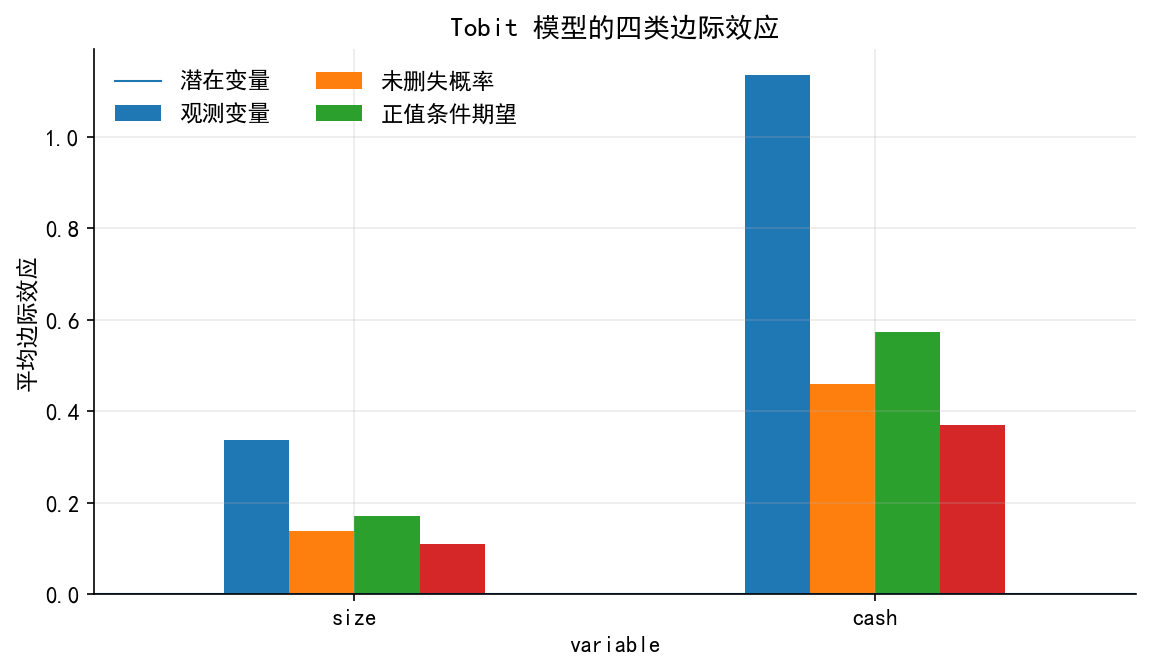

In [31]:
# ============================================================
# 可视化边际效应
# ============================================================

fig, ax = plt.subplots(figsize=(7.8, 4.6))

me_simple[["latent", "observed", "prob_pos", "positive"]].plot(kind="bar", ax=ax)

ax.axhline(0, linewidth=1)
ax.set_ylabel("平均边际效应")
ax.set_title("Tobit 模型的四类边际效应")
ax.legend(
    ["潜在变量", "观测变量", "未删失概率", "正值条件期望"],
    frameon=False,
    ncol=2
)

# 将横轴变量名改为水平方向显示
ax.tick_params(axis="x", labelrotation=0)

fig.tight_layout()
plt.show()

## Tobit 模型的进一步解读

本节从三个角度进一步理解 Tobit 模型。第一，比较 Tobit 与 OLS，说明为什么对受限因变量直接做 OLS 往往会产生偏误。第二，比较 Tobit、Probit 和 OLS，帮助理解 Tobit 同时包含“参与决策”和“数量决策”的信息。第三，总结 Tobit 的适用范围、局限性，并简要预告 Truncated regression、Two-part model 和 Heckman selection 等后续模型。

### Tobit 和 OLS 的对比

在实际研究中，如果因变量具有明显的边角解特征，例如大量样本满足 $y_i=0$，研究者有时会采用两种比较直接的 OLS 做法。

- 第一种做法是丢弃 $y_i=0$ 的样本，只保留 $y_i>0$ 的观察值，例如在 Stata 中执行 `reg y x if y>0`。
- 第二种做法是忽略因变量受限问题，直接使用全部样本估计线性模型，例如执行 `reg y x`。

这两种做法看起来简单，但一般都会导致有偏估计。关键原因是：删失机制改变了条件均值函数，OLS 所估计的线性条件均值不再是正确的模型。

先看第一种做法。若只使用 $y_i>0$ 的样本，实际上是在未删失样本中估计模型。对左删失 Tobit 而言，正值样本满足 $y_i=y_i^*$，但它们并不是从总体中随机抽出的普通连续样本，而是满足 $y_i^*>0$ 的条件样本。因此，正值部分的条件期望为：

$$
E(y_i \mid y_i>0,x_i)
=
x_i'\beta+
\sigma\lambda\left(\frac{x_i'\beta}{\sigma}\right)
$$

其中，$\lambda(z)$ 是 inverse Mills ratio，定义为：

$$
\lambda(z)=\frac{\phi(z)}{\Phi(z)}
$$

因此，在 $y_i>0$ 的子样本中，正确的条件均值并不是简单的 $x_i'\beta$，而是多了一项 $\sigma\lambda(x_i'\beta/\sigma)$。如果直接对正值样本做 OLS，相当于估计如下模型：

$$
y_i=x_i'\gamma+v_i
$$

但真实误差项中实际上包含被遗漏的非线性项：

$$
v_i=
\sigma\lambda\left(\frac{x_i'\beta}{\sigma}\right)+u_i
$$

由于 $\lambda(x_i'\beta/\sigma)$ 本身是 $x_i$ 的函数，通常有 $\mathrm{corr}(x_i,v_i)\neq 0$。这就产生了遗漏变量偏误。因此，`reg y x if y>0` 并不能得到 $\beta$ 的一致估计。

从直觉上看，这个结论也不难理解。正值样本是经过筛选后留下来的样本，它们的潜在变量 $y_i^*$ 已经超过删失点。若忽略这种筛选，只把正值样本当作普通随机样本来做 OLS，就会把“为什么这些样本能够进入正值区间”的信息遗漏掉。

::: {.callout-important}
### 避坑指南：不要只对正值样本做 OLS

`reg y x if y>0` 看起来是在分析“有正投入的企业”，但这个子样本并不是随机样本。企业能够进入 $y_i>0$ 区间，本身就与解释变量和误差项有关。因此，对正值样本直接做 OLS，通常不能解释为正值部分的无偏线性关系。
:::

再看第二种做法。如果使用全部样本直接做 OLS，即忽略 $y_i=0$ 是删失结果这一事实，则估计模型为：

$$
y_i=x_i'\gamma+e_i
$$

但 Tobit 模型下，观测变量的条件期望为：

$$
E(y_i\mid x_i)
=
\Phi(z_i)x_i'\beta+
\sigma\phi(z_i),
\quad
z_i=\frac{x_i'\beta}{\sigma}
$$

这说明 $E(y_i\mid x_i)$ 是 $x_i$ 的非线性函数，而不是简单的 $x_i'\beta$。相应地，$x_{ij}$ 对观测变量条件期望的边际效应为：

$$
\frac{\partial E(y_i\mid x_i)}{\partial x_{ij}}
=
\Phi(z_i)\beta_j
$$

由于 $0<\Phi(z_i)<1$，所以在通常情形下有：

$$
\left|
\frac{\partial E(y_i\mid x_i)}{\partial x_{ij}}
\right|
<
|\beta_j|
$$

这意味着，Tobit 系数 $\beta_j$ 是潜在变量 $y_i^*$ 层面的边际效应，而不是观测变量 $y_i$ 层面的边际效应。OLS 使用一条直线去拟合一个带有删失点和非线性条件均值的数据生成过程，因此会混淆潜在变量效应、进入正值区间的概率效应，以及正值部分的数量效应。

::: {.callout-note}
### 概念辨析：OLS 偏误来自哪里？

对 Tobit 数据直接做 OLS，问题不只是“0 太多”。更准确地说，问题在于观测变量 $y_i$ 的条件均值不是线性的 $x_i'\beta$。如果只保留 $y_i>0$ 的样本，还会额外引入样本选择后的遗漏变量偏误。
:::

### Tobit、Probit 和 OLS 的内在关系

Tobit、Probit 和 OLS 的核心区别在于如何处理 $y_i=0$ 和 $y_i>0$ 的信息。OLS 把 $y_i=0$ 当作普通连续值；Probit 把 $y_i=0$ 和 $y_i>0$ 压缩成两个类别；Tobit 则把 $y_i=0$ 理解为潜变量被删失后的观测结果，同时继续使用 $y_i>0$ 样本中的连续取值信息。

为了说明三者之间的关系，定义一个指示变量：

$$
d_i=
\begin{cases}
0, & y_i=0 \\
1, & y_i>0
\end{cases}
$$

在 Tobit 模型中，每个样本的似然贡献由两部分构成：若 $y_i=0$，使用被删失概率；若 $y_i>0$，使用连续密度。因此，Tobit 的似然函数可以写为：

$$
L(\beta,\sigma;y,x)
=
\prod_{i=1}^n
P(y_i=0\mid x_i)^{1-d_i}
 f(y_i\mid x_i,y_i>0)^{d_i}
$$

在 Probit 模型中，研究者只关心是否超过删失点，即 $d_i$ 是 0 还是 1。因此，Probit 的似然函数可以写为：

$$
L(\beta;y,x)
=
\prod_{i=1}^n
P(d_i=0\mid x_i)^{1-d_i}
P(d_i=1\mid x_i)^{d_i}
$$

在线性回归模型中，研究者把 $y_i$ 当作普通连续变量，直接使用连续密度来描述所有观测值：

$$
L(\beta,\sigma;y,x)
=
\prod_{i=1}^n f(y_i\mid x_i)
$$

由此可以更清楚地看出三者的差别。

- OLS 主要处理连续型数量决策，它把所有观测值都看作同一连续过程的结果。
- Probit 主要处理 0/1 参与决策，它只使用“是否超过 0”这一类信息。
- Tobit 同时使用两类信息：一是样本是否超过删失点，二是超过删失点后的连续取值是多少。

换个角度看，如果以 OLS 为基准，Tobit 主要处理的是部分样本在边界处被归并的问题；Probit 则可以视为一种更极端的归并，因为所有观测值都被压缩成 0 和 1 两类。因此，如果研究问题只关心 $P(y_i>0\mid x_i)$，Probit 可能已经足够；如果还关心 $y_i>0$ 后的取值大小，则需要考虑 Tobit、Two-part model 或其他相关模型。

::: {.callout-note}
### 概念辨析：Tobit 不是 Probit 加 OLS 的简单拼接

Tobit 同时利用“是否未删失”和“未删失后的连续取值”两类信息，但它假定二者由同一个潜变量过程驱动。如果研究者认为“是否参与”和“参与后的强度”由不同机制决定，Two-part model 往往比 Tobit 更合适。
:::

### Tobit 模型的适用范围和局限性

#### 何时适合使用 Tobit？

Tobit 适合以下情形：

- 存在一个潜在连续变量 $y_i^*$；
- 因变量在某个下限或上限处被删失；
- 同一套解释变量同时影响“是否超过删失点”和“超过后的取值大小”；
- 正值部分基本符合正态误差和同方差假设；
- 研究者关心潜在过程与观测结果之间的关系。

以企业研发投入为例，如果研究者认为企业存在一个潜在研发投入强度 $rd_i^*$，当 $rd_i^*\leq 0$ 时观测到 $rd_i=0$，当 $rd_i^*>0$ 时观测到实际研发投入强度，那么 Tobit 是一个自然的建模起点。

#### 何时不适合直接使用 Tobit？

Tobit 不适合以下情形：

- 0 值是企业主动选择，而不是删失；
- 参与决策和投入强度由不同机制决定；
- 正值部分高度偏态；
- 因变量是计数变量；
- 数据中存在大量结构性 0；
- 异方差严重；
- 样本进入数据本身存在选择偏误。

这些情形在金融数据中并不少见。例如，企业研发投入为 0 可能并不是因为潜在投入强度被压到 0，而是企业根本没有研发部门、没有创新战略，或者处于完全不同的业务模式中。此时，$rd_i=0$ 更像是一种结构性选择，而不是简单的左删失结果。

::: {.callout-important}
### 避坑指南：先判断 0 的经济含义，再选择模型

看到大量 0 值，并不意味着一定要使用 Tobit。更重要的问题是：这些 0 是否可以解释为潜在连续变量被下限删失？如果 0 代表一种独立的经济选择，应该优先考虑 Two-part model、Hurdle model 或选择模型。
:::

### Tobit 模型的替代模型

Tobit 是分析受限因变量的重要起点，但不是唯一选择。实际建模时，应根据数据生成过程和研究问题选择模型。

| 研究问题 | 更合适的模型 | Stata 参考命令 | Python 实现思路 |
|---|---|---|---|
| 是否参与和参与强度是两个过程 | Two-part model | `twopm` 或手动分两步估计 | `Logit` / `Probit` + `OLS` / `GLM` |
| 先跨过门槛，再决定正值大小 | Hurdle model | `churdle` 或相关用户命令 | 连续结果可手动两步估计；计数结果可使用 hurdle count model |
| 因变量是比例，位于 $[0,1]$ | Fractional response model | `fracreg` | `GLM` + `Binomial` family |
| 因变量是计数 | Poisson / PPML | `poisson`，`ppmlhdfe` | `Poisson` 或 `GLM` + `Poisson` family |
| 样本进入数据存在选择 | Heckman selection | `heckman` | 通常自定义 two-step 或使用第三方实现 |
| 样本被截断而不是删失 | Truncated regression | `truncreg` | 通常自写 MLE；计数截断模型可使用 truncated count model |

::: {.callout-tip}
### 提示词：判断 Tobit 是否适合自己的研究问题

我正在分析一个因变量为 `你的因变量名` 的模型。这个变量有大量 0 值，核心解释变量是 `核心解释变量名`，控制变量包括 `控制变量列表`。请帮我判断是否适合使用 Tobit 模型，并从以下角度给出建议：

1. 这些 0 值更像是删失结果、结构性选择，还是计数结果？
2. 是否应该使用 Tobit、Two-part model、Hurdle model、Poisson / PPML 或 Heckman selection？
3. 如果使用 Tobit，应该如何解释系数和边际效应？
4. 如果不适合使用 Tobit，应该如何重新设定模型？

请用金融实证研究的语言回答，并给出 Python 或 Stata 的基本代码框架。
:::

本节的核心结论是：Tobit 模型既不是 OLS 的简单替代，也不是“处理 0 值”的通用工具。它依赖一个明确的潜变量和删失机制。只有当研究者能够从经济含义上说明 $y_i=0$ 是潜在连续变量被边界约束后的观测结果时，Tobit 才是合适的起点。若参与决策、数量决策和样本进入机制本身不同，则应考虑更灵活的替代模型。

## 案例：企业研发投入强度

本节把前面的内容整理成一个 mini-paper 风格的分析案例。案例关注企业规模、现金持有、资产负债率、成长性和盈利能力如何影响研发投入强度。

### 研究背景

企业研发投入具有明显的受限因变量特征。一部分企业没有研发投入，另一部分企业存在正的研发投入强度。Tobit 模型的经济解释是：企业是否投入研发可以理解为潜在研发投入净收益是否为正。设：

$$
rd_i^*
=
MR_i - MC_i
$$

当 $rd_i^*>0$ 时，企业进行研发投入；当 $rd_i^*\leq 0$ 时，企业不进行研发投入，观测到 $rd_i=0$。因此：

$$
rd_i=
\max(0,rd_i^*)
$$

扩展模型设定为：

$$
rd_i^*
=
\beta_0
+
\beta_1 size_i
+
\beta_2 cash_i
+
\beta_3 lev_i
+
\beta_4 growth_i
+
\beta_5 profit_i
+
u_i
$$

其中：

- $size_i$：企业规模；
- $cash_i$：现金持有；
- $lev_i$：资产负债率；
- $growth_i$：成长性；
- $profit_i$：盈利能力；
- $rd_i^*$：潜在研发投入净收益或潜在投入强度；
- $rd_i$：实际观测到的研发投入强度。

### 数据特征：描述性统计与可视化

因变量分布、0 值比例和核心解释变量的描述性统计如下。

![研发投入强度分布](./figs/limit_dep_tobit_fig02_rd_distribution.png)

![删失点附近的数据特征](./figs/limit_dep_tobit_fig03_censoring_pattern.png)

![潜在变量与观测变量](./figs/limit_dep_tobit_fig04_latent_rd.png)

::: {.callout-note}
### Stata 对应命令：描述性统计与可视化

```stata
*------------------------------------------------------------
* 描述性统计与相关系数
*------------------------------------------------------------
summarize rd size cash lev growth profit, detail

pwcorr rd size cash lev growth profit, sig star(0.05)

*------------------------------------------------------------
* 因变量分布图
*------------------------------------------------------------
capture mkdir "./figs"
histogram rd, ///
    percent ///
    title("研发投入强度分布") ///
    xtitle("研发投入强度 rd") ///
    ytitle("比例")

graph export "./figs/limit_dep_tobit_stata_rd_hist.png", ///
    width(1800) replace
```
::: 

In [32]:
# ============================================================
# 描述性统计表
# ============================================================

vars_case = ["rd", "size", "cash", "lev", "growth", "profit"]

summary_case = df[vars_case].agg(["count", "mean", "std", "min", "median", "max"]).T
summary_case["p25"] = df[vars_case].quantile(0.25)
summary_case["p75"] = df[vars_case].quantile(0.75)

display(summary_case[["count", "mean", "std", "min", "p25", "median", "p75", "max"]].round(2))

print(f"因变量 rd=0 的比例: {(df['rd'] == 0).mean():.2%}")
print(f"正研发投入样本中 rd 的均值: {df.loc[df['rd'] > 0, 'rd'].mean():.3f}")

,count,mean,std,min,p25,median,p75,max
rd,2500.0,0.22,0.38,0.00,0.00,0.00,0.33,2.37
size,2500.0,-0.01,1.01,-3.57,-0.70,-0.02,0.68,3.16
cash,2500.0,0.31,0.16,0.01,0.19,0.29,0.41,0.88
lev,2500.0,0.43,0.20,0.01,0.29,0.42,0.58,0.96
growth,2500.0,0.07,0.21,-0.84,-0.08,0.08,0.22,0.82
profit,2500.0,0.05,0.08,-0.17,-0.00,0.05,0.11,0.32


因变量 rd=0 的比例: 59.44%
正研发投入样本中 rd 的均值: 0.553


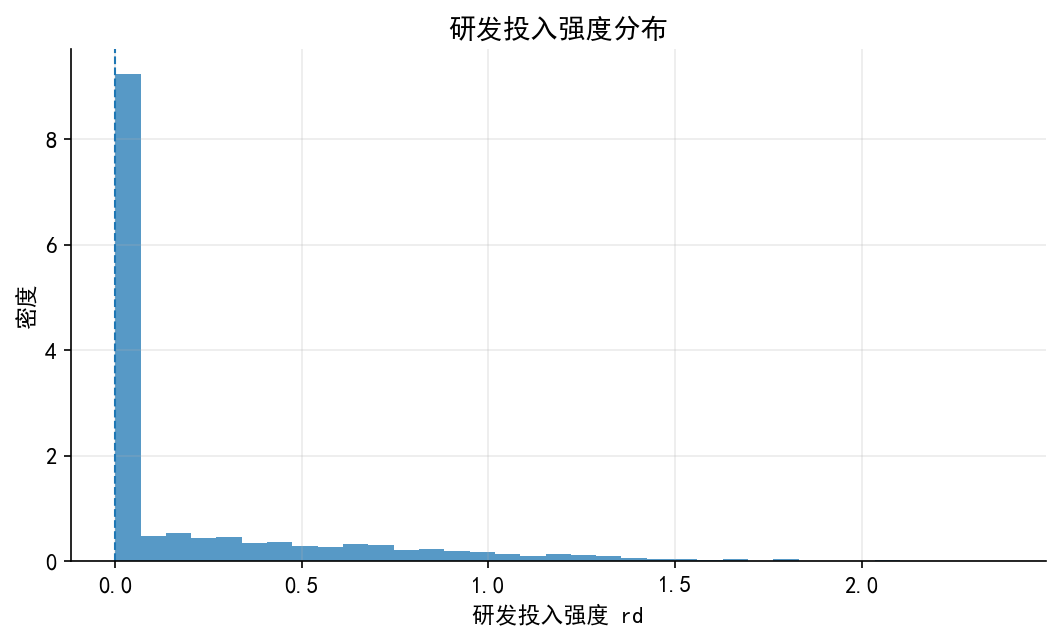

In [33]:
# ============================================================
# 可视化：因变量分布
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 4.4))

ax.hist(df["rd"], bins=35, alpha=0.75, density=True)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("研发投入强度 rd")
ax.set_ylabel("密度")
ax.set_title("研发投入强度分布")

fig.tight_layout()
plt.show()

In [34]:
# ============================================================
# 相关系数矩阵
# ============================================================

corr_case = df[vars_case].corr()
display(corr_case.round(3))

,rd,size,cash,lev,growth,profit
rd,1.000,0.354,0.193,-0.108,0.161,0.050
size,0.354,1.000,-0.003,0.027,-0.002,-0.027
cash,0.193,-0.003,1.000,0.023,0.004,0.008
lev,-0.108,0.027,0.023,1.000,-0.001,0.002
growth,0.161,-0.002,0.004,-0.001,1.000,-0.040
profit,0.050,-0.027,0.008,0.002,-0.040,1.000


### 回归模型设定

案例依次估计四个模型。第一个模型是 OLS 基准设定：

$$
rd_i
=
\alpha
+
\beta_1 size_i
+
\beta_2 cash_i
+
\varepsilon_i
$$

该模型忽略了 $rd_i$ 在 0 点的删失特征。随后估计三个 Tobit 设定。简化版 Tobit 为：

$$
rd_i^*
=
\alpha
+
\beta_1 size_i
+
\beta_2 cash_i
+
u_i
$$

进一步加入资产负债率：

$$
rd_i^*
=
\alpha
+
\beta_1 size_i
+
\beta_2 cash_i
+
\beta_3 lev_i
+
u_i
$$

完整模型为：

$$
rd_i^*
=
\alpha
+
\beta_1 size_i
+
\beta_2 cash_i
+
\beta_3 lev_i
+
\beta_4 growth_i
+
\beta_5 profit_i
+
u_i
$$

所有 Tobit 模型的观测规则均为：

$$
rd_i=\max(0,rd_i^*)
$$

Python 中，如果模型都是 `statsmodels` 的 OLS / GLM 对象，可以使用 `summary_col`、`pystout` 或 `pyfixest` 的 `etable()` 来生成类似 Stata `esttab` 的回归表。但本章同时包含 OLS 和自定义 Tobit 估计结果，通用回归表包对这种混合对象的支持有限。因此，本案例采用“统一整理为 `pandas.DataFrame`，再用 `great_tables` 可选美化”的方案：估计过程保持清晰，输出表格也便于导出为 HTML、LaTeX 或 Markdown。

::: {.callout-note}
### Stata 对应命令：`esttab` 输出 OLS 与 Tobit 表格

Stata 中可以使用 `esttab` 或 `outreg2` 快速整理回归表。下面以 `esttab` 为例。

```stata
*------------------------------------------------------------
* 如未安装 esttab，先安装 estout 包
*------------------------------------------------------------
capture mkdir "./output"

capture which esttab
if _rc{
    ssc install estout, replace
}

*------------------------------------------------------------
* 估计多个模型
*------------------------------------------------------------
eststo clear

eststo OLS: regress rd size cash lev growth profit, ///
    vce(robust)

eststo Tobit1: tobit rd size cash, ///
    ll(0) vce(robust)

eststo Tobit2: tobit rd size cash lev, ///
    ll(0) vce(robust)

eststo Tobit3: tobit rd size cash lev growth profit, ///
    ll(0) vce(robust)

*------------------------------------------------------------
* 输出回归表
*------------------------------------------------------------
esttab OLS Tobit1 Tobit2 Tobit3 using "./output/tobit_reg_table.rtf", ///
    replace ///
    b(%9.3f) se(%9.3f) ///
    star(* 0.10 ** 0.05 *** 0.01) ///
    mtitles("OLS" "Tobit (1)" "Tobit (2)" "Tobit (3)") ///
    stats(N ll, ///
          fmt(%9.0f %9.2f) ///
          labels("Observations" "Log likelihood")) ///
    title("OLS 与 Tobit 回归结果")
```
::: 

In [35]:
# ============================================================
# 估计 OLS 和 Tobit 的多个设定
# ============================================================

# 三组解释变量
specs = {
    "M1: size + cash": ["size", "cash"],
    "M2: + lev": ["size", "cash", "lev"],
    "M3: + growth + profit": ["size", "cash", "lev", "growth", "profit"]
}

ols_results = {}
tobit_results = {}

for name, xvars in specs.items():
    X = sm.add_constant(df[xvars])
    ols_results[name] = sm.OLS(df["rd"], X).fit(cov_type="HC1")
    tobit_results[name] = fit_tobit(df["rd"], X, left=0.0, name=name)

print("模型估计完成。")

模型估计完成。


In [36]:
# ============================================================
# 整理回归结果表
# ============================================================

def stars(p):
    # 根据 p 值添加显著性星号。
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def fmt_coef(coef, pval):
    # 第一行显示系数和显著性星号。
    return f"{coef:.3f}{stars(pval)}"


def fmt_stat(stat):
    # 第二行显示 t 值或 z 值。
    return f"({stat:.2f})"


def sm_result_to_table(res):
    # 把 statsmodels 回归结果整理成统一格式。
    return pd.DataFrame({
        "coef": res.params,
        "se": res.bse,
        "stat": res.tvalues,
        "p": res.pvalues
    })


def tobit_result_to_table(fit):
    # 把自定义 Tobit 结果整理成统一格式。
    tab = fit["table"].copy()
    return pd.DataFrame({
        "coef": tab["coef"],
        "se": tab["std_err"],
        "stat": tab["z"],
        "p": tab["p_value"]
    })


def make_reg_table(model_tables, row_order, model_stats=None):
    # 生成类似 esttab / outreg2 的回归表。
    # model_tables: {"模型名": DataFrame}
    # row_order   : 变量显示顺序
    # model_stats : {"统计量名": {"模型名": 数值}}
    out_rows = []

    for var in row_order:
        coef_row = {"variable": var}
        stat_row = {"variable": ""}
        for model_name, tab in model_tables.items():
            if var in tab.index:
                coef_row[model_name] = fmt_coef(tab.loc[var, "coef"], tab.loc[var, "p"])
                stat_row[model_name] = fmt_stat(tab.loc[var, "stat"])
            else:
                coef_row[model_name] = ""
                stat_row[model_name] = ""
        out_rows.extend([coef_row, stat_row])

    if model_stats is not None:
        for stat_name, values in model_stats.items():
            row = {"variable": stat_name}
            for model_name in model_tables.keys():
                val = values.get(model_name, "")
                if isinstance(val, float):
                    row[model_name] = f"{val:.3f}"
                else:
                    row[model_name] = val
            out_rows.append(row)

    return pd.DataFrame(out_rows)


# 需要输出的模型
ols_full = ols_results["M3: + growth + profit"]

model_tables = {
    "OLS": sm_result_to_table(ols_full),
    "Tobit (1)": tobit_result_to_table(tobit_results["M1: size + cash"]),
    "Tobit (2)": tobit_result_to_table(tobit_results["M2: + lev"]),
    "Tobit (3)": tobit_result_to_table(tobit_results["M3: + growth + profit"]),
}

model_stats = {
    "Observations": {name: len(df) for name in model_tables.keys()},
    "Share rd=0": {name: float((df["rd"] == 0).mean()) for name in model_tables.keys()},
    "Log-likelihood": {
        "OLS": float(ols_full.llf),
        "Tobit (1)": tobit_results["M1: size + cash"]["llf"],
        "Tobit (2)": tobit_results["M2: + lev"]["llf"],
        "Tobit (3)": tobit_results["M3: + growth + profit"]["llf"],
    },
    "AIC": {
        "OLS": float(ols_full.aic),
        "Tobit (1)": tobit_results["M1: size + cash"]["aic"],
        "Tobit (2)": tobit_results["M2: + lev"]["aic"],
        "Tobit (3)": tobit_results["M3: + growth + profit"]["aic"],
    },
    "BIC": {
        "OLS": float(ols_full.bic),
        "Tobit (1)": tobit_results["M1: size + cash"]["bic"],
        "Tobit (2)": tobit_results["M2: + lev"]["bic"],
        "Tobit (3)": tobit_results["M3: + growth + profit"]["bic"],
    },
}

reg_table = make_reg_table(
    model_tables=model_tables,
    row_order=["const", "size", "cash", "lev", "growth", "profit"],
    model_stats=model_stats
)

# 若安装了 great_tables，则使用更适合展示的表格格式；
# 若未安装，则直接显示 pandas 表格。
try:
    from great_tables import GT

    gt_table = (
        GT(reg_table)
        .tab_header(title="OLS 与 Tobit 回归结果")
        .tab_source_note(
            source_note="括号内为 t 值或 z 值；***、**、* 分别表示 1%、5%、10% 显著性水平。"
        )
    )
    display(gt_table)
except ImportError:
    display(reg_table)


GT(_tbl_data=          variable        OLS  Tobit (1)  Tobit (2)  Tobit (3)
0            const   0.147***  -0.525***  -0.286***  -0.386***
1                      (6.88)   (-12.97)    (-6.47)    (-9.13)
2             size   0.137***   0.338***   0.339***   0.342***
3                     (18.97)    (19.67)    (17.15)    (18.87)
4             cash   0.471***   1.134***   1.148***   1.149***
5                     (10.34)    (11.02)    (17.67)     (3.85)
6              lev  -0.237***             -0.560***  -0.557***
7                     (-6.79)               (-6.68)    (-3.10)
8           growth   0.293***                         0.734***
9                      (8.80)                          (16.73)
10          profit   0.319***                         0.872***
11                     (3.64)                           (2.78)
12    Observations       2500       2500       2500       2500
13      Share rd=0      0.594      0.594      0.594      0.594
14  Log-likelihood   -864.209  -1794.627  -1770.132  -1710.869
15             AIC   1740.418   3597.255   3550.265   3435.738
16             BIC   1775.362   3620.551   3579.385   3476.506, _body=<great_tables._gt_data.Body object at 0x0000025EC23BA4D0>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='variable', column_align='left', column_width=None), ColInfo(var='OLS', type=<ColInfoTypeEnum.default: 1>, column_label='OLS', column_align='right', column_width=None), ColInfo(var='Tobit (1)', type=<ColInfoTypeEnum.default: 1>, column_label='Tobit (1)', column_align='right', column_width=None), ColInfo(var='Tobit (2)', type=<ColInfoTypeEnum.default: 1>, column_label='Tobit (2)', column_align='right', column_width=None), ColInfo(var='Tobit (3)', type=<ColInfoTypeEnum.default: 1>, column_label='Tobit (3)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000025EC22AC3D0>, _spanners=Spanners([]), _heading=Heading(title='OLS 与 Tobit 回归结果', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000025EC2687B50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000025EC2102E10>, _source_notes=['括号内为 t 值或 z 值；***、**、* 分别表示 1%、5%、10% 显著性水平。'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000025EC2687CD0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_bor

从回归表可以看到，OLS 和 Tobit 对核心变量的估计结果通常不会完全相同。OLS 估计的是观测变量 $rd_i$ 的线性条件均值，而 Tobit 估计的是潜在变量 $rd_i^*$ 的线性方程，并通过删失规则连接到观测变量 $rd_i$。

因此，Tobit 回归表只是第一步。若论文或研究报告关心实际观测到的研发投入强度，还需要进一步报告边际效应。

In [37]:
# ============================================================
# 完整 Tobit 模型的边际效应
# ============================================================

fit_full = tobit_results["M3: + growth + profit"]
X_full = sm.add_constant(df[specs["M3: + growth + profit"]])

me_full = tobit_marginal_effects(fit_full, X_full)
display(me_full.round(4))

,latent,observed,prob_pos,positive
variable,,,,
size,0.3419,0.1388,0.1724,0.1124
cash,1.1487,0.4662,0.5791,0.3777
lev,-0.5573,-0.2262,-0.2810,-0.1833
growth,0.7340,0.2979,0.3701,0.2414
profit,0.8721,0.3540,0.4396,0.2868


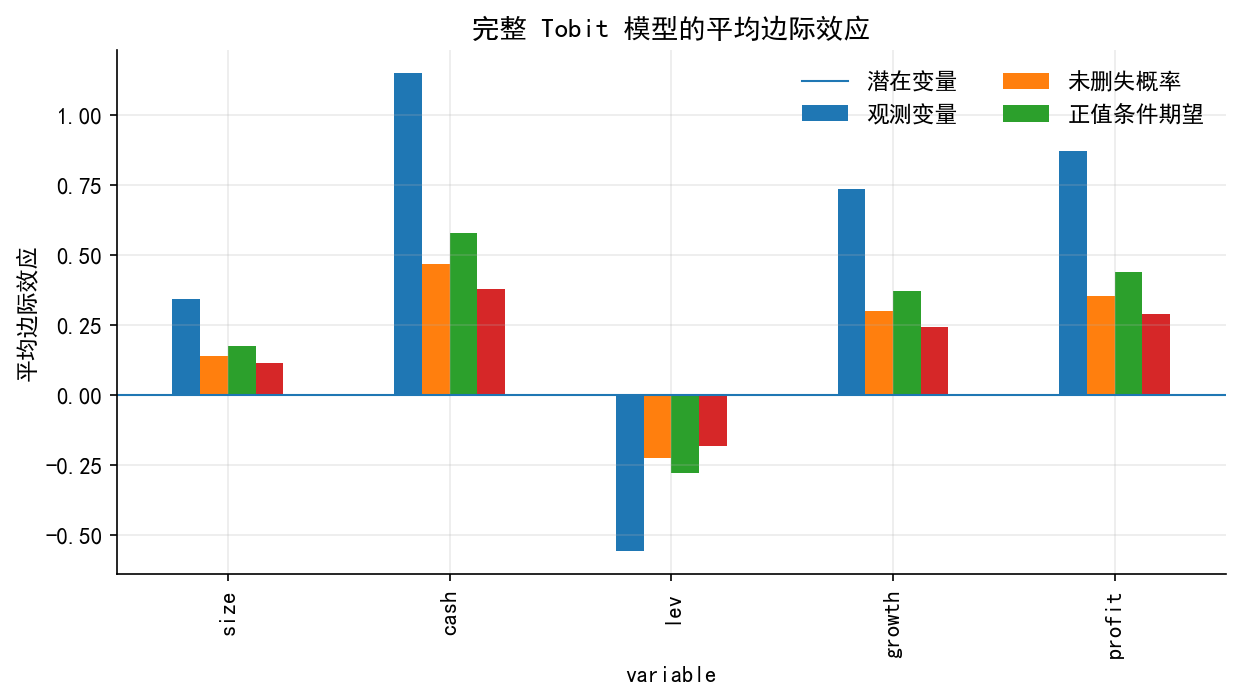

In [38]:
# ============================================================
# 边际效应可视化
# ============================================================

fig, ax = plt.subplots(figsize=(8.4, 4.8))

me_full[["latent", "observed", "prob_pos", "positive"]].plot(kind="bar", ax=ax)

ax.axhline(0, linewidth=1)
ax.set_ylabel("平均边际效应")
ax.set_title("完整 Tobit 模型的平均边际效应")
ax.legend(
    ["潜在变量", "观测变量", "未删失概率", "正值条件期望"],
    frameon=False,
    ncol=2
)

fig.tight_layout()
plt.show()

::: {.callout-note}
### Stata 对应命令：Tobit 边际效应

Stata 的 `margins` 可以直接计算 Tobit 模型的不同边际效应。下面以完整模型为例。

```stata
*------------------------------------------------------------
* 完整 Tobit 模型
*------------------------------------------------------------
tobit rd size cash lev growth profit, ///
    ll(0) vce(robust)

* 对潜在变量 E(rd* | x) 的影响
margins, dydx(size cash lev growth profit) ///
    predict(xb)

* 对观测变量 E(rd | x) 的影响
margins, dydx(size cash lev growth profit) ///
    predict(ystar(0, .))

* 对未删失概率 P(rd > 0 | x) 的影响
margins, dydx(size cash lev growth profit) ///
    predict(pr(0, .))

* 对正值条件期望 E(rd | rd > 0, x) 的影响
margins, dydx(size cash lev growth profit) ///
    predict(e(0, .))
```
::: 

### 现金持有的预测曲线

为了让边际效应更直观，可以固定其他变量在样本均值，只改变现金持有 `cash`，然后画出：

- $P(rd_i>0\mid x_i)$；
- $E(rd_i\mid x_i)$；
- $E(rd_i\mid rd_i>0,x_i)$。

这三个对象分别对应参与概率、总体期望投入强度和正值样本条件期望。

![现金持有与研发投入概率](./figs/limit_dep_tobit_fig05_cash_prob.png)

![现金持有与期望研发投入强度](./figs/limit_dep_tobit_fig06_cash_expected_rd.png)

![平均边际效应对比](./figs/limit_dep_tobit_fig07_marginal_effects.png)

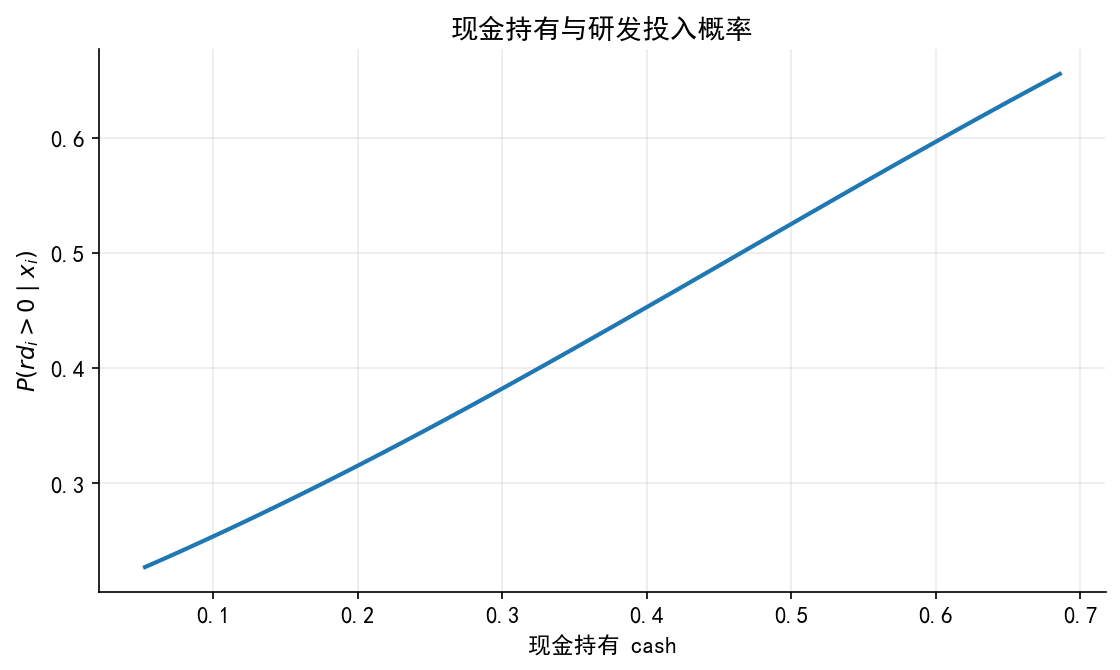

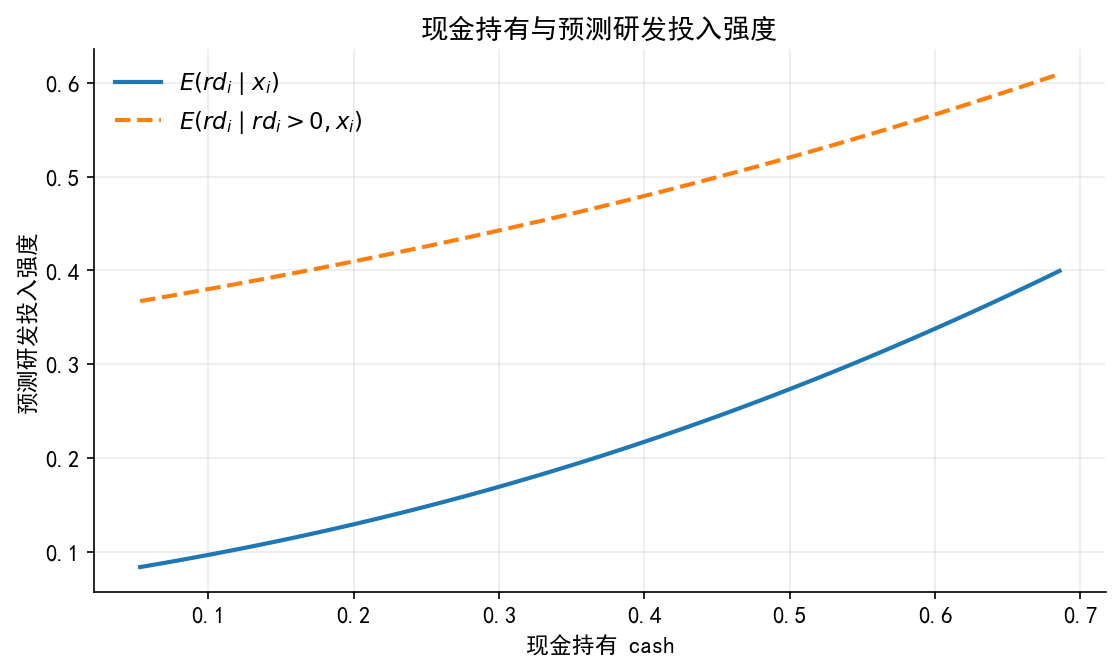

In [39]:
# ============================================================
# 根据估计结果绘制 cash 的预测曲线
# ============================================================

cash_grid = np.linspace(df["cash"].quantile(0.02), df["cash"].quantile(0.98), 100)

# 构造预测数据：除 cash 外，其余变量固定在样本均值
pred_df = pd.DataFrame({
    "size": df["size"].mean(),
    "cash": cash_grid,
    "lev": df["lev"].mean(),
    "growth": df["growth"].mean(),
    "profit": df["profit"].mean()
})

X_pred = sm.add_constant(pred_df, has_constant="add")

beta = fit_full["beta"]
sigma = fit_full["sigma"]
xb = X_pred @ beta
z = xb / sigma

pred_df["prob_pos"] = norm.cdf(z)
pred_df["E_y"] = norm.cdf(z) * xb + sigma * norm.pdf(z)
pred_df["E_y_pos"] = xb + sigma * norm.pdf(z) / np.clip(norm.cdf(z), 1e-12, None)

fig, ax = plt.subplots(figsize=(7.6, 4.6))

ax.plot(pred_df["cash"], pred_df["prob_pos"], linewidth=2)
ax.set_xlabel("现金持有 cash")
ax.set_ylabel(r"$P(rd_i>0\mid x_i)$")
ax.set_title("现金持有与研发投入概率")

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.6, 4.6))

ax.plot(pred_df["cash"], pred_df["E_y"], linewidth=2, label=r"$E(rd_i\mid x_i)$")
ax.plot(pred_df["cash"], pred_df["E_y_pos"], linewidth=2, linestyle="--",
        label=r"$E(rd_i\mid rd_i>0,x_i)$")

ax.set_xlabel("现金持有 cash")
ax.set_ylabel("预测研发投入强度")
ax.set_title("现金持有与预测研发投入强度")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

### 案例小结

这个案例可以形成如下结论：

- 研发投入强度具有明显的 0 点堆积，直接使用 OLS 可能忽略潜在删失机制；
- Tobit 模型把企业研发投入解释为潜在净收益 $rd_i^*=MR_i-MC_i$ 经过左删失后的观测结果；
- 企业规模和现金持有不仅可能影响潜在研发投入强度，也可能影响企业是否进行研发投入；
- 实证分析中不宜只报告 Tobit 系数，应进一步报告对 $E(rd_i\mid x_i)$ 和 $P(rd_i>0\mid x_i)$ 的平均边际效应；
- 如果研究者认为“是否投入研发”和“投入多少”由不同机制决定，则 Two-part model 可能比 Tobit 更合适。

::: {.callout-tip}
### 提示词：生成 mini-paper 风格的 Tobit 分析

我正在写一个关于 `你的研究主题` 的实证分析。因变量 `y` 在 0 点有大量取值，核心解释变量是 `x_main`，控制变量包括 `controls`。请参考 Tobit 模型的 mini-paper 写法，帮我组织以下内容：

1. 研究背景和变量经济含义；
2. 为什么因变量可以理解为潜在变量被左删失；
3. 描述性统计和 0 值比例；
4. OLS 与 Tobit 的模型设定；
5. Tobit 系数和三类边际效应的解释；
6. 如果 Tobit 不合适，应该考虑哪些替代模型。

请使用学术论文风格，但语言要适合课程论文。
:::

## 附录 A：手写 Tobit MLE

正文使用 `fit_tobit()` 直接估计。本附录展示其背后的手写 MLE 逻辑。

设左删失点为 0。对单个样本，若 $y_i=0$，其似然贡献为：

$$
\Phi\left(-\frac{x_i'\beta}{\sigma}\right)
$$

若 $y_i>0$，其似然贡献为：

$$
\frac{1}{\sigma}
\phi\left(
\frac{y_i-x_i'\beta}{\sigma}
\right)
$$

因此，负对数似然函数可以直接写成 Python 函数，然后使用 `scipy.optimize.minimize()` 最小化。

In [40]:
# ============================================================
# 附录 A：手写 MLE 版本
# ============================================================

from scipy.optimize import minimize

def neg_loglike_tobit(params, y, X, left=0.0):
    # 左删失 Tobit 的负对数似然函数。
    #
    # 参数说明：
    #   params: [beta_0, beta_1, ..., beta_k, log_sigma]
    #   y     : 因变量
    #   X     : 解释变量矩阵，需要包含常数项
    #   left  : 左删失点

    beta = params[:-1]
    sigma = np.exp(params[-1])

    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    xb = X @ beta

    cens = y <= left + 1e-12
    ll = np.empty_like(y, dtype=float)

    # y=left 的样本：概率贡献
    z_left = (left - xb[cens]) / sigma
    ll[cens] = norm.logcdf(z_left)

    # y>left 的样本：密度贡献
    z = (y[~cens] - xb[~cens]) / sigma
    ll[~cens] = norm.logpdf(z) - np.log(sigma)

    return -np.sum(ll)


# 使用完整模型演示手写 MLE
y = df["rd"].values
X = X_full.values

# 初始值：用 OLS 结果作为 beta 初始值，用 OLS 残差标准差作为 sigma 初始值
ols_start = sm.OLS(y, X).fit()
start_params = np.r_[ols_start.params, np.log(np.std(ols_start.resid))]

opt = minimize(
    neg_loglike_tobit,
    x0=start_params,
    args=(y, X, 0.0),
    method="BFGS"
)

beta_mle = pd.Series(opt.x[:-1], index=X_full.columns)
sigma_mle = np.exp(opt.x[-1])

print("手写 MLE 是否收敛:", opt.success)
print("sigma:", round(sigma_mle, 3))
display(beta_mle.round(3))

手写 MLE 是否收敛: False
sigma: 0.634


const    -0.386
size      0.342
cash      1.149
lev      -0.557
growth    0.734
profit    0.872
dtype: float64

## 附录 B：删失正态与截断正态

Tobit 模型中经常会出现“截断正态”相关公式，但需要注意一个细节：Tobit 的观测变量 $y_i$ 不是简单的截断正态分布，而是一个混合结构：

- 在 0 点有一个离散概率质量；
- 在 $y_i>0$ 的部分有连续密度。

具体来说：

$$
P(y_i=0\mid x_i)
=
\Phi\left(
-\frac{x_i'\beta}{\sigma}
\right)
$$

而当我们条件在 $y_i>0$ 的样本上时，正值部分的条件密度为：

$$
f(y_i\mid x_i,y_i>0)
=
\frac{
\frac{1}{\sigma}
\phi\left(
\frac{y_i-x_i'\beta}{\sigma}
\right)
}{
\Phi\left(
\frac{x_i'\beta}{\sigma}
\right)
},
\quad y_i>0
$$

这里第二个式子是截断正态密度。它和 Tobit 似然中的未删失样本密度贡献不同。Tobit 似然中，未删失样本贡献的是：

$$
f(y_i\mid x_i)
=
\frac{1}{\sigma}
\phi\left(
\frac{y_i-x_i'\beta}{\sigma}
\right)
$$

而不是条件密度 $f(y_i\mid x_i,y_i>0)$。原因是 Tobit 的总体似然已经通过 $y_i=0$ 部分的概率贡献处理了删失概率，不需要再对正值样本密度进行条件化。

### 截断正态的条件期望

如果：

$$
y_i^*\mid x_i\sim N(\mu_i,\sigma^2)
$$

其中 $\mu_i=x_i'\beta$，并且条件在 $y_i^*>0$ 上，则：

$$
E(y_i^*\mid y_i^*>0,x_i)
=
\mu_i
+
\sigma
\frac{\phi(\mu_i/\sigma)}{\Phi(\mu_i/\sigma)}
$$

记：

$$
\lambda(z_i)
=
\frac{\phi(z_i)}{\Phi(z_i)},\quad z_i=\frac{\mu_i}{\sigma}
$$

则：

$$
E(y_i\mid y_i>0,x_i)
=
\mu_i+\sigma\lambda(z_i)
$$

这个结果解释了为什么只用正值样本做 OLS 会有偏。因为正值样本的条件均值不是简单的 $x_i'\beta$，而是多了一项与 $x_i$ 有关的逆米尔斯比率。

## 课堂小结

核心结论可以概括为五点：

- Tobit 模型适用于潜在连续变量被下限或上限删失的情形；
- 看到大量 0 不等于一定要使用 Tobit，关键是判断 0 的经济含义；
- Tobit 的似然函数由 0 点概率和正值部分密度共同构成；
- Tobit 系数首先解释潜在变量 $y_i^*$，不能直接当作观测变量 $y_i$ 的边际效应；
- 实证分析中通常应重点报告 $E(y_i\mid x_i)$ 和 $P(y_i>0\mid x_i)$ 的平均边际效应。

思考题：

- 为什么 $y_i=0$ 的样本在 Tobit 中不是普通连续观测值？
- 企业研发投入为 0 更像删失结果，还是更像真实选择结果？
- 如果参与决策和投入强度由不同因素决定，Tobit 会有什么问题？
- Tobit、Two-part model 和 Heckman selection model 分别适合什么数据结构？

## 参考文献

- Tobin, J. (1958). Estimation of relationships for limited dependent variables. Econometrica, 26(1), 24–36. [Link](https://doi.org/10.2307/1907382), [PDF](http://sci-hub.ren/10.2307/1907382), [Google](https://scholar.google.com/scholar?q=Estimation+of+relationships+for+limited+dependent+variables).

- Cragg, J. G. (1971). Some statistical models for limited dependent variables with application to the demand for durable goods. Econometrica, 39(5), 829–844. [Link](https://doi.org/10.2307/1909582), [PDF](http://sci-hub.ren/10.2307/1909582), [Google](https://scholar.google.com/scholar?q=Some+statistical+models+for+limited+dependent+variables+with+application+to+the+demand+for+durable+goods).

- McDonald, J. F., & Moffitt, R. A. (1980). The uses of Tobit analysis. The Review of Economics and Statistics, 62(2), 318–321. [Link](https://doi.org/10.2307/1924766), [PDF](http://sci-hub.ren/10.2307/1924766), [Google](https://scholar.google.com/scholar?q=The+uses+of+Tobit+analysis).

- Amemiya, T. (1984). Tobit models: A survey. Journal of Econometrics, 24(1–2), 3–61. [Link](https://doi.org/10.1016/0304-4076(84)90074-5), [PDF](http://sci-hub.ren/10.1016/0304-4076(84)90074-5), [Google](https://scholar.google.com/scholar?q=Tobit+models+A+survey).

- Belotti, F., Deb, P., Manning, W. G., & Norton, E. C. (2015). twopm: Two-part models. The Stata Journal, 15(1), 3–20. [Link](https://doi.org/10.1177/1536867X1501500102), [PDF](https://journals.sagepub.com/doi/pdf/10.1177/1536867X1501500102), [Google](https://scholar.google.com/scholar?q=twopm+Two-part+models).

- Sánchez-Peñalver, A. (2019). Estimation methods in the presence of corner solutions. The Stata Journal, 19(1), 87–111. [Link](https://doi.org/10.1177/1536867X19830893), [PDF](https://journals.sagepub.com/doi/pdf/10.1177/1536867X19830893), [Google](https://scholar.google.com/scholar?q=Estimation+methods+in+the+presence+of+corner+solutions).